$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 2.3

## 理论

给定设计点集合 $D = \{\boldsymbol{x}_1, \dots, \boldsymbol{x}_n\}$ 以及对应的函数观测值 $y_i = h(\boldsymbol{x}_i)$（$i = 1, \dots, n$），我们希望构造如下形式的插值函数：

$$
h_n(\boldsymbol{x}) = \sum_{i=1}^{n} \beta_i R_i(\boldsymbol{x})
$$

式中 $R_i(\boldsymbol{x})$ 为关于变量 $\boldsymbol{x}$ 的一组基函数，$i = 1, \dots, n$。为了在维度 $p\ge2$ 时仍然具有普适性，基函数 $R_i(\boldsymbol{x})$ 的选择必须依赖于数据采样点。据此令：

$$
R_i(\boldsymbol{x}) = R(\boldsymbol{x} - \boldsymbol{x}_i)
$$

其中映射关系为 $R: \mathbb{R}^p \to \mathbb{R}$。

插值条件可推导出如下 $n$ 个方程

$$
\sum_{j=1}^{n}\beta_j R(\boldsymbol{x}_i -\boldsymbol{x}_j) = y_i,\quad i = 1, \dots, n
$$

写成矩阵形式，该方程组可表示为 $\boldsymbol{R}\boldsymbol{\beta} = \boldsymbol{y}$。其中 $\boldsymbol{R}$ 为 $n$ 阶方阵，其第 $i$ 行第 $j$ 列元素为 $R(\boldsymbol{x}_i-\boldsymbol{x}_j)$；$\boldsymbol{\beta}=(\beta_1, \dots, \beta_n)'$，$\boldsymbol{y}=(y_1, \dots, y_n)'$。若矩阵 $\boldsymbol{R}$ 非奇异，则可求得唯一解 $\hat{\boldsymbol{\beta}} = \boldsymbol{R}^{-1}\boldsymbol{y}$，由此得到径向基函数插值器

$$
\hat{y}(\boldsymbol{x}) = \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{y}
\tag{2.6}
$$

式中 $\boldsymbol{r}(\boldsymbol{x})$ 是 $n\times1$ 维向量，其第 $i$ 个分量为 $R(\boldsymbol{x}-\boldsymbol{x}_i)$。

已知正定矩阵必然可逆，为了让正定矩阵的任一子矩阵均为正定矩阵，可以令矩阵中的每个元素均由含有正定性质的函数组成，这引出了正定函数的定义：

> **定义 2.1** 若对于任意设计 $D = \{\boldsymbol{x}_1, \dots, \boldsymbol{x}_n\}$ 以及任意向量 $\boldsymbol{c} = (c_1, \dots, c_n)'$，均满足
> $$\sum_{i=1}^{n}\sum_{j=1}^{n}c_ic_jR(\boldsymbol{x}_i - \boldsymbol{x}_j) \ge 0 \tag{2.7}$$
> 则称连续函数 $R: \mathbb{R}^p \to \mathbb{R}$ 在 $\mathbb{R}^p$ 上半正定。若式 (2.7) 仅在 $\boldsymbol{c}=\boldsymbol{0}$ 时取等号，则称函数 $R(\cdot)$ 正定。

一方面，为了简化模型，另外要求正定函数亦是径向函数，另一方面，工程中的参数大多具有各向同性，这正是径向函数的概念：

> **定义 2.2** 若存在函数 $\psi: \mathbb{R}^+ \to \mathbb{R}$，使得 $R(\boldsymbol{x}) = \psi(\|\boldsymbol{x}\|)$（其中 $\|\cdot\|$ 一般为欧几里得范数），则称函数 $R: \mathbb{R}^p \to \mathbb{R}$ 为径向函数。

径向基函数存在多种可选类型，高斯函数便是其中一例：

$$
R(\boldsymbol{x}) = \exp\left(-\frac{\|\boldsymbol{x}\|^2}{\theta^2}\right)
\tag{2.8}
$$

再次回顾式 (2.1) 中的一维算例

$$
h(x)=\frac{\sin(10\pi x)}{1 + 64(x - 0.25)^2} + x^2,\quad x\in[0,1]
\tag{2.1}
$$

取区间 $[0,1]$ 内 $n=10$ 个等距节点构成集合 $D$，即 $D=\{(i-1)/(n-1)\}_{i=1}^n$。选取式 (2.8) 中的高斯函数作为径向基函数。图 2.3 展示了三组不同 $\theta$ 取值下的径向基函数插值结果。不难发现，当 $\theta=0.1$ 时径向基插值效果十分理想；$\theta=1$ 时插值效果欠佳（表现与图 2.1 左子图相近）；而 $\theta=0.01$ 时插值效果极差。接下来的问题是如何决定参数。

调节径向基函数长度尺度参数的一种方法是采用交叉验证。留一交叉验证误差的表达式为：

$$
cv_i = y_i −\hat{y}_{\sim i}(\boldsymbol{x}_i)
$$

式中 $\hat{y}_{\sim i}(\boldsymbol{x}_i)$ 代表舍弃第 $i$ 组数据点后，由径向基插值模型在 $\boldsymbol{x}=\boldsymbol{x}_i$ 位置得到的预测值。式 (2.6) 舍去 $i$ 行 $i$ 列可得 $\hat{y}_{\sim i}(\boldsymbol{x}_i) = \boldsymbol{r}_{\sim i}(\boldsymbol{x}_i)'(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{y}_{\sim i}$，其中 $\boldsymbol{r}_{\sim i}$ 表示向量 $\boldsymbol{r}$ 剔除第 $i$ 个元素后的向量（$\boldsymbol{y}_{\sim i}$ 同理），$\boldsymbol{R}_{\sim i}$ 为矩阵 $\boldsymbol{R}$ 去掉第 $i$ 行与第 $i$ 列后得到的矩阵。对 $n$ 阶方阵求逆的计算复杂度为 $\mathcal{O}(n^3)$。因此若依次求解 $i=1,2,\dots,n$ 对应的留一交叉验证误差 $cv_i$，整体计算复杂度将达到 $\mathcal{O}(n^4)$；所幸存在一种简便算法：

> **引理 2.1** 假定分块矩阵维度适配，则
> $$\begin{bmatrix}\boldsymbol{A} & \boldsymbol{B} \\ \boldsymbol{C} & \boldsymbol{D}\end{bmatrix}^{-1}=\begin{bmatrix}\boldsymbol{A}^{-1} + \boldsymbol{A}^{-1}\boldsymbol{B}\boldsymbol{Q}^{-1}\boldsymbol{C}\boldsymbol{A}^{-1} & -\boldsymbol{A}^{-1}\boldsymbol{B}\boldsymbol{Q}^{-1} \\-\boldsymbol{Q}^{-1}\boldsymbol{C}\boldsymbol{A}^{-1} & \boldsymbol{Q}^{-1}\end{bmatrix}$$
> 且
> $$\begin{vmatrix}\boldsymbol{A} & \boldsymbol{B} \\ \boldsymbol{C} & \boldsymbol{D}\end{vmatrix}= |\boldsymbol{A}| |\boldsymbol{Q}|$$
> 其中 $\boldsymbol{Q} = \boldsymbol{D} - \boldsymbol{C}\boldsymbol{A}^{-1}\boldsymbol{B}$。

为简化记号，在 $\boldsymbol{r}_{\sim i}(\boldsymbol{x}_i)$ 中省略自变量 $\boldsymbol{x}_i$。由于我们只关心 $\boldsymbol{R}$ 去掉某一行 / 列后的变化，而不在乎行列之间的顺序，因此可将矩阵 $\boldsymbol{R}$ 重新排列为

$$
\boldsymbol{R} =
\begin{bmatrix}
\boldsymbol{R}_{\sim i} & \boldsymbol{r}_{\sim i} \\
\boldsymbol{r}_{\sim i}' & R(\boldsymbol{x}_i - \boldsymbol{x}_i)
\end{bmatrix}
$$

由径向函数的定义可知 $$R(\boldsymbol{x}_i - \boldsymbol{x}_i)=R(\boldsymbol{0})=1$$

因此：

$$
\boldsymbol{R}^{-1}=
\begin{bmatrix}
\boldsymbol{R}_{\sim i} & \boldsymbol{r}_{\sim i} \\
\boldsymbol{r}'_{\sim i} & 1
\end{bmatrix}^{-1}=
\begin{bmatrix}
(\boldsymbol{R}_{\sim i})^{-1}+(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{r}_{\sim i}\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}/\boldsymbol{Q} & -(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{r}_{\sim i}/\boldsymbol{Q} \\
-\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}/\boldsymbol{Q} & 1/\boldsymbol{Q}
\end{bmatrix}
$$

其中 $\boldsymbol{Q} = 1 - \boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{r}_{\sim i}$。考察该矩阵最后一行，

$$
(\boldsymbol{R}^{-1})_{ii}=1/\boldsymbol{Q}
$$

$$
(\boldsymbol{R}^{-1})_{i\sim i}=-\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}/\boldsymbol{Q}
$$

容易推出：

$$
\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1} = -\frac{(\boldsymbol{R}^{-1})_{i\sim i}}{(\boldsymbol{R}^{-1})_{ii}}
$$

式中 $(\boldsymbol{R}^{-1})_{i\sim i}$ 代表矩阵 $\boldsymbol{R}^{-1}$ 的第 $i$ 行去掉第 $i$ 个元素后构成的行向量。由此可得：

$$\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{y}_{\sim i} = -\frac{(\boldsymbol{R}^{-1})_{i\sim i}}{(\boldsymbol{R}^{-1})_{ii}}\boldsymbol{y}_{\sim i}$$

由于

$$
\frac{(\boldsymbol{R}^{-1})_i \boldsymbol{y}}{(\boldsymbol{R}^{-1})_{ii}} = \frac{1}{(\boldsymbol{R}^{-1})_{ii}}
\begin{bmatrix}
(\boldsymbol{R}^{-1})_{i\sim i} & (\boldsymbol{R}^{-1})_{ii}
\end{bmatrix}

\begin{bmatrix}
\boldsymbol{y}_{\sim i} \\ y_{i}
\end{bmatrix} =

\frac{(\boldsymbol{R}^{-1})_{i\sim i}}{(\boldsymbol{R}^{-1})_{ii}}\boldsymbol{y}_{\sim i} + y_i
$$

进而得到：

$$
\boldsymbol{r}'_{\sim i}(\boldsymbol{R}_{\sim i})^{-1}\boldsymbol{y}_{\sim i} = -\frac{(\boldsymbol{R}^{-1})_{i\sim i}}{(\boldsymbol{R}^{-1})_{ii}}\boldsymbol{y}_{\sim i} = -\frac{(\boldsymbol{R}^{-1})_i \boldsymbol{y}}{(\boldsymbol{R}^{-1})_{ii}} + y_i
$$

$$
cv_i = y_i −\hat{y}_{\sim i}(\boldsymbol{x}_i) = \frac{(\boldsymbol{R}^{-1})_i \boldsymbol{y}}{(\boldsymbol{R}^{-1})_{ii}}
\tag{2.9}
$$

利用该简便计算公式，只需对矩阵 $\boldsymbol{R}$ 做一次求逆运算，即可算出所有 $i=1,2,\dots,n$ 对应的 $cv_i$。

针对图 2.3 中的示例，通过最小化均方交叉验证误差

$$
MSCV = \frac{1}{n}\sum_{i=1}^{n}cv_i^2
\tag{2.10}
$$

解得 $\hat{\theta}=0.08$，该取值所得结果与图 2.3 中间子图的效果高度接近，拟合效果优异。

## 实践

创建画布宽 30 英寸、高 10 英寸，将画布分为 1x3。依据公式

$$
h(x)=\frac{\sin(10\pi x)}{1 + 64(x - 0.25)^2} + x^2,\quad x\in[0,1]
\tag{2.1}
$$

创建函数 f(x)。在 $[0,1]$ 上等距取 301 个点作为图像的绘图点的横坐标，令其为 test，并计算 f(test) 作为绘图点的纵坐标，令其为 true。令 n=10，依据均匀区间端点公式

$$
D=\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}
$$

取 1:n 上的等距 n 个点作为观测点的横坐标，命名为 D。计算 D 上的函数值作为观测值，令其为 y。为了计算高斯核，先计算 $\|\boldsymbol{x}\|$，令其为 E。

当 theta=0.01 时，依据公式

$$
R(\boldsymbol{x}) = \exp\left(-\frac{\|\boldsymbol{x}\|^2}{\theta^2}\right)
\tag{2.8}
$$

计算高斯核 R。依据公式

$$
\hat{\boldsymbol{\beta}} = \boldsymbol{R}^{-1}\boldsymbol{y}
$$

计算 $\hat{\boldsymbol{\beta}}$，令其为 coef。依据公式

$$
\boldsymbol{r}(\boldsymbol{x})_{i}=R(\boldsymbol{x}-\boldsymbol{x}_i)
$$

计算 $\boldsymbol{r}(\boldsymbol{x})$，令其为 R_pred。依据公式

$$
\hat{y}(\boldsymbol{x}) = \boldsymbol{r}(\boldsymbol{x})'\hat{\boldsymbol{\beta}}
\tag{2.6}
$$

计算 $\hat{y}(\boldsymbol{x})$，令其为 pred。绘制真实函数图像，其中类型为 l，线宽为 4，线型为 2，x 轴标注为 x，y 轴标注为 y，大小为 2，y 轴范围为 c(min(true)-.25,max(true)+.25)，大小为 2，标题为 expression(theta==0.1)，大小为 4。叠加观测点图像，其中点型为 16，大小为 2，颜色为 blue。叠加预测函数图像，其中颜色为 3，线宽为 4。

当 theta=0.1 时，依据公式

$$
R(\boldsymbol{x}) = \exp\left(-\frac{\|\boldsymbol{x}\|^2}{\theta^2}\right)
\tag{2.8}
$$

计算高斯核 R。依据公式

$$
\hat{\boldsymbol{\beta}} = \boldsymbol{R}^{-1}\boldsymbol{y}
$$

计算 $\hat{\boldsymbol{\beta}}$，令其为 coef。依据公式

$$
\boldsymbol{r}(\boldsymbol{x})_{i}=R(\boldsymbol{x}-\boldsymbol{x}_i)
$$

计算 $\boldsymbol{r}(\boldsymbol{x})$，令其为 R_pred。依据公式

$$
\hat{y}(\boldsymbol{x}) = \boldsymbol{r}(\boldsymbol{x})'\hat{\boldsymbol{\beta}}
\tag{2.6}
$$

计算 $\hat{y}(\boldsymbol{x})$，令其为 pred。绘制真实函数图像，其中类型为 l，线宽为 4，线型为 2，x 轴标注为 x，y 轴标注为 y，大小为 2，y 轴范围为 c(min(true)-.25,max(true)+.25)，大小为 2，标题为 expression(theta==0.1)，大小为 4。叠加观测点图像，其中点型为 16，大小为 2，颜色为 blue。叠加预测函数图像，其中颜色为 3，线宽为 4。

当 theta=1 时，依据公式

$$
R(\boldsymbol{x}) = \exp\left(-\frac{\|\boldsymbol{x}\|^2}{\theta^2}\right)
\tag{2.8}
$$

计算高斯核 R。依据公式

$$
\hat{\boldsymbol{\beta}} = \boldsymbol{R}^{-1}\boldsymbol{y}
$$

计算 $\hat{\boldsymbol{\beta}}$，令其为 coef。依据公式

$$
\boldsymbol{r}(\boldsymbol{x})_{i}=R(\boldsymbol{x}-\boldsymbol{x}_i)
$$

计算 $\boldsymbol{r}(\boldsymbol{x})$，301 个点按行拼接，转为向量令其为 R_pred。依据公式

$$
\hat{y}(\boldsymbol{x}) = \boldsymbol{r}(\boldsymbol{x})'\hat{\boldsymbol{\beta}}
\tag{2.6}
$$

计算 $\hat{y}(\boldsymbol{x})$，301 个点按行拼接，转为向量令其为 pred。绘制真实函数图像，其中类型为 l，线宽为 4，线型为 2，x 轴标注为 x，y 轴标注为 y，大小为 2，y 轴范围为 c(min(true)-.25,max(true)+.25)，大小为 2，标题为 expression(theta==0.1)，大小为 4。叠加观测点图像，其中点型为 16，大小为 2，颜色为 blue。叠加预测函数图像，其中颜色为 3，线宽为 4。添加图例，其中位置为 (0.25,-0.5)，图例内容为 c("真实值","预测值")，线型为 c(2,1)，颜色为 c(1,3)，线宽为 c(4,4)，边框类型为 n，大小为 2。将画布还原回 1x1。

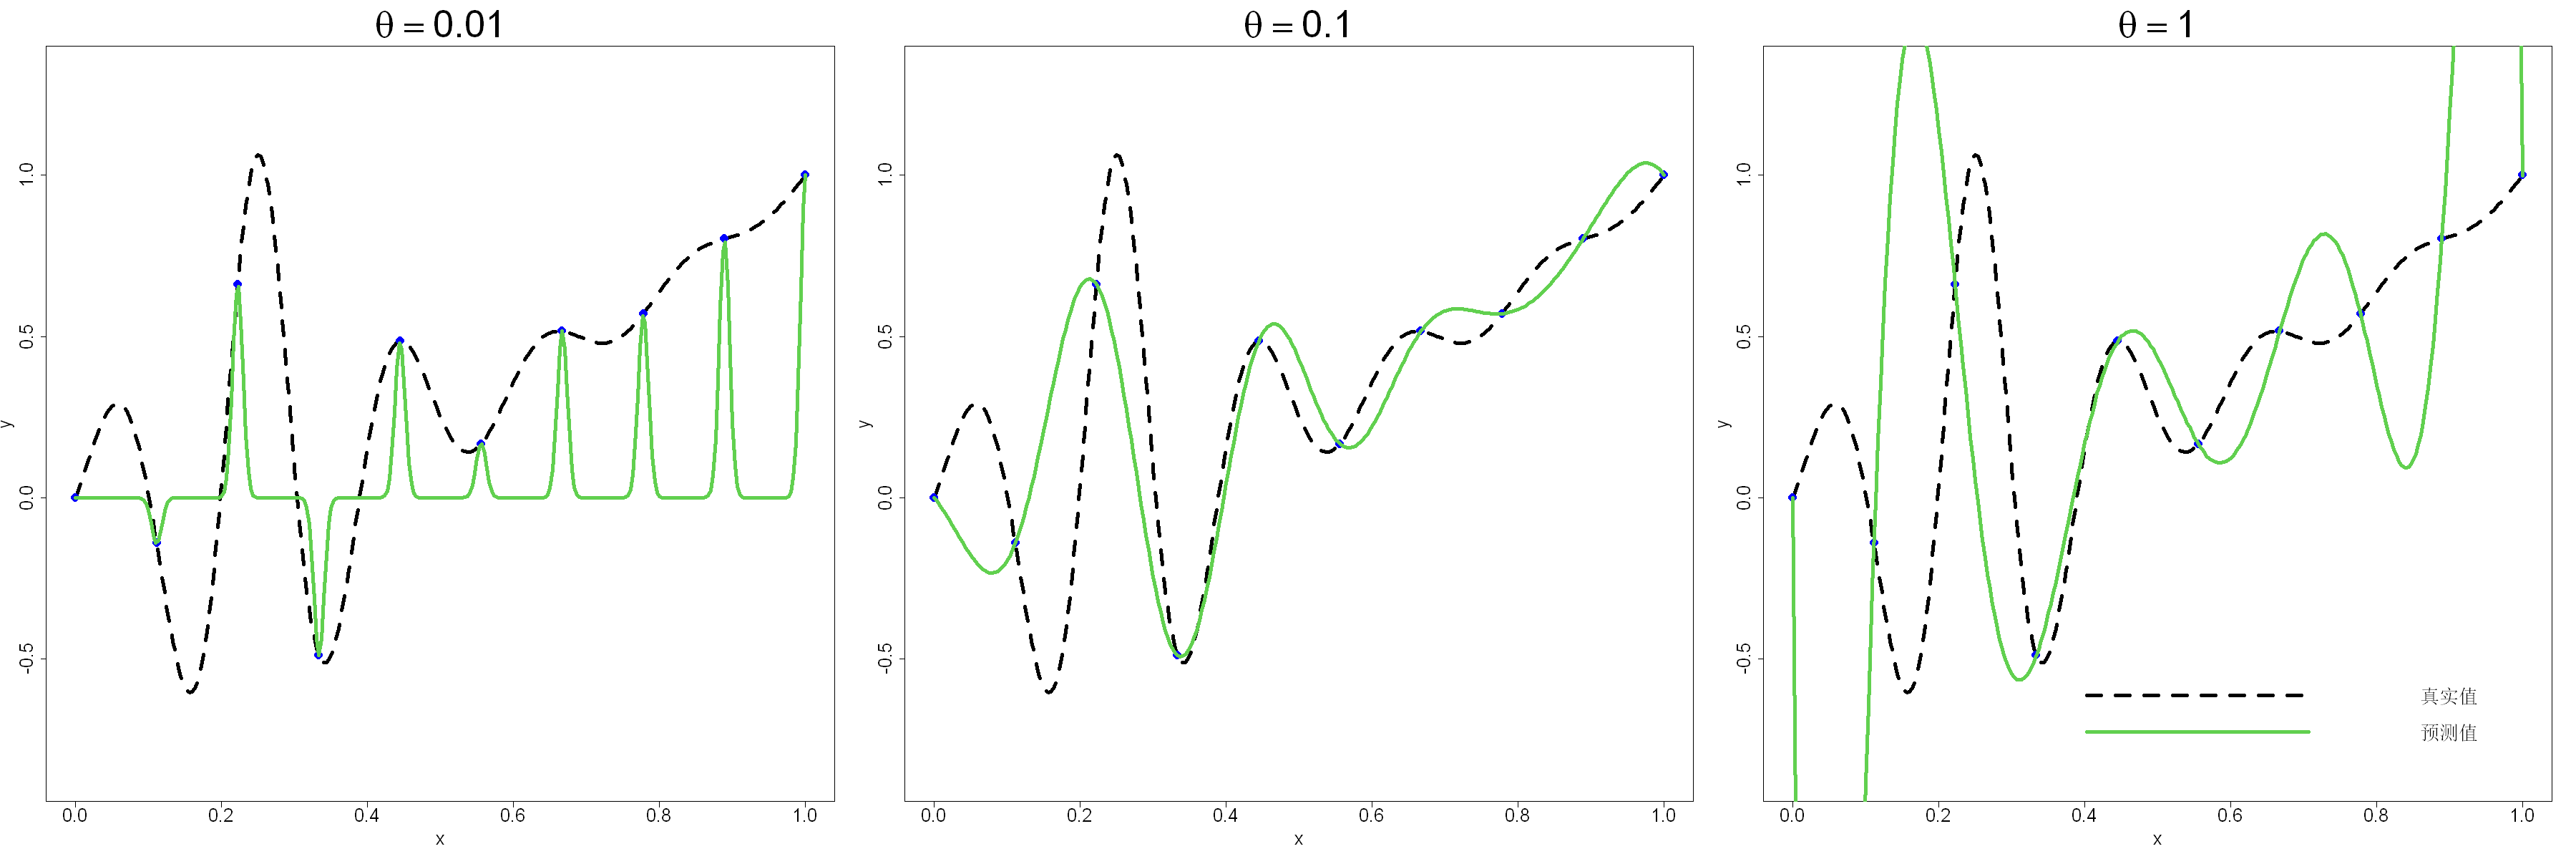

In [1]:
options(repr.plot.width=30,repr.plot.height=10)
par(mfrow=c(1,3))
f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
D=((1:n)-1)/(n-1)
y=f(D)
E=outer(D,D,"-")

theta=.01
R=exp(-(E/theta)^2) # 10x10
coef=solve(R,y) # 10x1
R_pred=exp(-(outer(test,D,"-")/theta)^2) # 301x10
pred=as.vector(R_pred%*%coef) # 301x1
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main=expression(theta==0.01),cex.main=4)
points(D,y,pch=16,cex=2,col="blue")
lines(test,pred,col=3,lwd=4)

theta=.1
R=exp(-(E/theta)^2) # 10x10
coef=solve(R,y) # 10x1
R_pred=exp(-(outer(test,D,"-")/theta)^2) # 301x10
pred=as.vector(R_pred%*%coef) # 301x1
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main=expression(theta==0.1),cex.main=4)
points(D,y,pch=16,cex=2,col="blue")
lines(test,pred,col=3,lwd=4)

theta=1
R=exp(-(E/theta)^2) # 10x10
coef=solve(R,y) # 10x1
R_pred=exp(-(outer(test,D,"-")/theta)^2) # 301x10
pred=as.vector(R_pred%*%coef) # 301x1
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main=expression(theta==1),cex.main=4)
points(D,y,pch=16,cex=2,col="blue")
lines(test,pred,col=3,lwd=4)
legend(.25,-.5,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(4,4),bty="n",cex=2)
par(mfrow=c(1,1))

依据

$$
h(x)=\frac{\sin(10\pi x)}{1 + 64(x - 0.25)^2} + x^2,\quad x\in[0,1]
$$

定义函数 f(x)。令 n=10，依据均匀设计公式

$$
D=\left\{\frac{i-0.5}{n}\right\}_{i=1}^{n}
$$

取 1:n 上的等距 n 个点，令其为 D。对每个横坐标计算函数值得到其纵坐标，命名为 y。依据公式

$$
MSCV = \frac{1}{n}\sum_{i=1}^{n}cv_i^2
$$

创建函数 MSCV(theta)。使用 1 维优化函数 optimize() 对 MSCV(theta) 进行优化，优化区间为 [0,1]，取最小值为最终优化结果，的确是 0.08。

In [2]:
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
n=10
D=((1:n)-1)/(n-1)
y=f(D)
MSCV=function(theta){
  Rinv=solve(exp(-(outer(D,D,"-")/theta)^2))
  mean((c(Rinv%*%y)/diag(Rinv))^2)
}
optimize(MSCV,c(0,1))$min

[1] 0.08066227

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$